# BSM benchmark로 보는 CRR·GBM Monte Carlo 수렴

본 노트북에서는 src에 구현한 CRR price 모델, Monte Carlo price 모델의 수렴성을 시각화하는 그래프를 작성한다.

Figure 1은 CRR의 홀수·짝수 step 에 대해서 옵션가격이 BSM에 수렴하는 것을 보여준다.

Figure 2는 Monte Carlo 가격+95% 신뢰구간을 보여주고, 표준오차가 $M^{-1/2}$ 로 감소함을 보여준다.

In [2]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root_candidates = (Path.cwd(), *Path.cwd().parents)
PROJECT_ROOT = next(
    (path for path in project_root_candidates if (path / "pyproject.toml").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root")

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from option_pricing_volatility.models.binomial import crr_price
from option_pricing_volatility.models.bsm import bsm_price
from option_pricing_volatility.simulation.monte_carlo import mc_price

pd.options.display.float_format = "{:,.10f}".format
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## 벤치마킹 데이터

현 노트북은 "구현한 모델의 수렴성"을 판단하므로,  실제 시장데이터는 필요없다.

따라서, 간단한 분석을 위해 벤치마킹용 시장 데이터를 입력하고, BSM 가격을 계산한다.

In [3]:
S = 100.0
K = 100.0
T = 1.0
r = 0.05
q = 0.0
sigma = 0.20
seed = 42
option_type = "call"

bsm_benchmark = bsm_price(
    spot=S,
    strike=K,
    maturity=T,
    rate=r,
    volatility=sigma,
    option_type=option_type,
    dividend_yield=q,
)

pd.Series(
    {
        "spot": S,
        "strike": K,
        "maturity_years": T,
        "continuous_rate": r,
        "continuous_dividend_yield": q,
        "annual_volatility": sigma,
        "seed": seed,
        "bsm_call_price": bsm_benchmark,
    },
    name="value",
)

spot                        100.0000000000
strike                      100.0000000000
maturity_years                1.0000000000
continuous_rate               0.0500000000
continuous_dividend_yield     0.0000000000
annual_volatility             0.2000000000
seed                         42.0000000000
bsm_call_price               10.4505835722
Name: value, dtype: float64

## 1. CRR Binomial convergence

`2**k - 1`과 `2**k`를 `k=3,...,12`에서 짝지은 log-scale grid를 사용한다. 

홀수, 짝수트리는 BSM 기준에 대해서 반대 방향에서 시작해서 동일한 점으로 수렴한다.

`relative_error`는 절대오차를 BSM 가격으로 나눈 값이며, `absolute_error / S`를 사용하여서 

In [ ]:

# 3~12의 지수에 대해 2^3,2^3-1 .. 을 만든다. 각 스텝마다 첫번째 숫자는 even tree기준, 두번째 숫자는 odd tree 이다. 
step_grid = sorted(
    steps
    for exponent in range(3, 13)
    for steps in (2**exponent - 1, 2**exponent)
)

# 위에서 입력한 step에 대해서, crr price를 계산한다. 
crr_rows = []
for steps in step_grid:
    price = crr_price(
        spot=S,
        strike=K,
        maturity=T,
        rate=r,
        volatility=sigma,
        steps=steps,
        option_type=option_type,
        dividend_yield=q,
    )

    # crr 가격과 bsm 가격의 절대오차
    absolute_error = abs(price - bsm_benchmark)
    crr_rows.append(
        {
            "steps": steps,
            "parity": "even" if steps % 2 == 0 else "odd",
            "crr_price": price,
            "bsm_price": bsm_benchmark,
            "absolute_error": absolute_error,
            "relative_error": absolute_error / abs(bsm_benchmark),
        }
    )

crr_df = pd.DataFrame(crr_rows)

"""
파이썬 딕셔너리로 추가한 리스트를 df 로 변경.

crr_df["steps"].eq(4096)  ->  "steps"열 ( pd.Series 객체 ) 을 가져오고, "==4096" 필터링을 거친,  boolean Series을 만든다.

crr_df.loc[]  =>  마스킹 인자를 받아서, True인 부분의 "행" 을 ( pd.Series ) 로 가져온다.

.iloc[0]  =>  해당 Series에서 0번째 "행"을 가져와라 라는 의미. 

즉, 이 코드 한줄은  "steps 가 4096인 행들을 모아서, 그 행들중 첫번째 행을 가져와라" 라는 의미.
"""
crr_4096 = crr_df.loc[crr_df["steps"].eq(4096)].iloc[0]  

# 이부분은 쉽다.  스텝이 첫번째로 4096이 된 행에서,  절대오차/S 를 계산하고, 그값이  1/10000 임을 assert하라는 의미. 
crr_error_over_spot = float(crr_4096["absolute_error"] / S)
crr_4096_check = crr_error_over_spot < 1e-4
assert crr_4096_check
crr_df

,steps,parity,crr_price,bsm_price,absolute_error,relative_error
0,7,odd,10.7037895031,10.4505835722,0.2532059309,0.0242288796
1,8,even,10.2050994160,10.4505835722,0.2454841562,0.0234899950
2,15,odd,10.5681535182,10.4505835722,0.1175699460,0.0112500843
3,16,even,10.3266510458,10.4505835722,0.1239325264,0.0118589096
4,31,odd,10.5073030438,10.4505835722,0.0567194716,0.0054273975
5,32,even,10.3883456011,10.4505835722,0.0622379711,0.0059554541
6,63,odd,10.4784491939,10.4505835722,0.0278656217,0.0026664178
7,64,even,10.4194001028,10.4505835722,0.0311834694,0.0029838974
8,127,odd,10.4643955311,10.4505835722,0.0138119589,0.0013216448
9,128,even,10.4349761567,10.4505835722,0.0156074154,0.0014934492


## 데이터 시각화
matplotlib을 이용하여 데이터를 시각화.



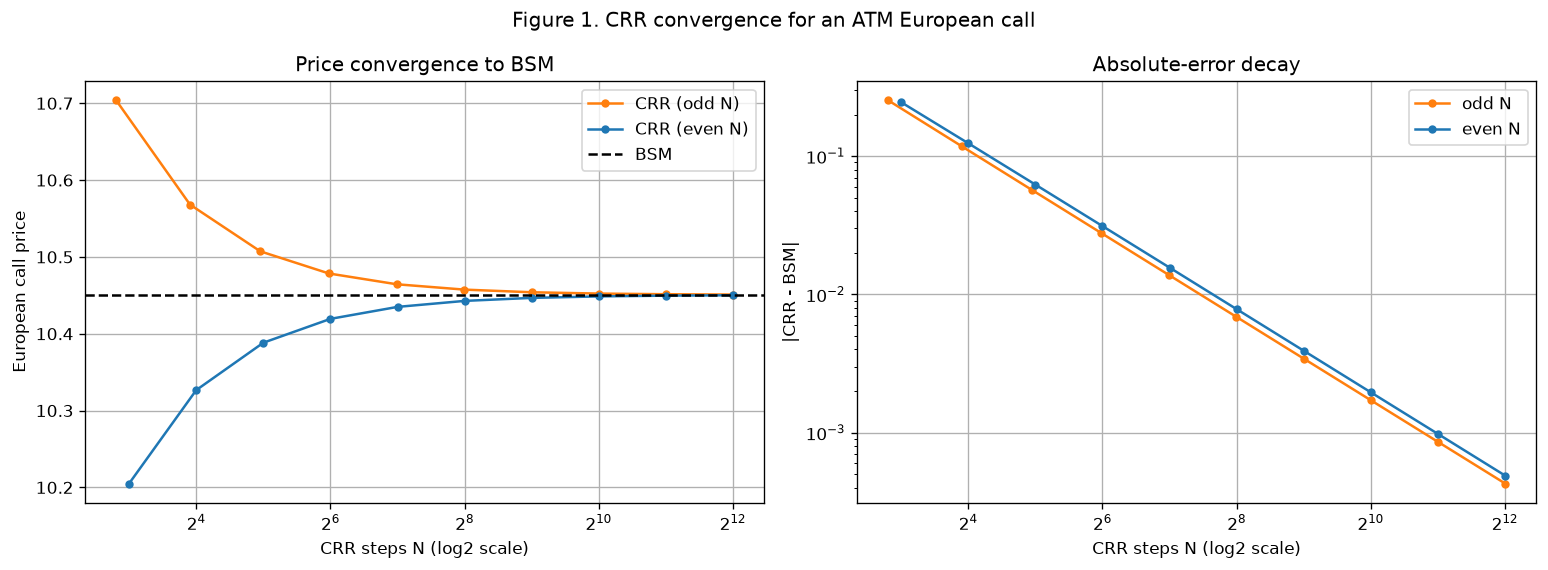

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = {"odd": "tab:orange", "even": "tab:blue"}


"""
.groupby 는 파라미터의 label을 기준으로 해서, pandas df iterator를 생성한다.

여기서는 parity=odd,  parity=even 인 2개의 df가 iterater가 된다. 
"""
for parity, group in crr_df.groupby("parity", sort=False):

    # 0번째(왼쪽)그래프에는 steps - crr price 인 그래프를 odd/even으로 나누어 그린다.
    axes[0].plot(
        group["steps"],
        group["crr_price"],
        marker="o",
        markersize=4,
        color=colors[parity],
        label=f"CRR ({parity} N)",
    )

    # 1번째(오른쪽)그래프에는 steps-abs_err  인 그래프를 odd/even으로 구분해 그린다. 
    axes[1].plot(
        group["steps"],
        group["absolute_error"],
        marker="o",
        markersize=4,
        color=colors[parity],
        label=f"{parity} N",
    )

axes[0].axhline(
    bsm_benchmark, color="black", linestyle="--", linewidth=1.5, label="BSM"
)
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("CRR steps N (log2 scale)")
axes[0].set_ylabel("European call price")
axes[0].set_title("Price convergence to BSM")
axes[0].legend()

axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("CRR steps N (log2 scale)")
axes[1].set_ylabel("|CRR - BSM|")
axes[1].set_title("Absolute-error decay")
axes[1].legend()

fig.suptitle("Figure 1. CRR convergence for an ATM European call")
fig.tight_layout()
plt.show()

## 2. GBM Monte Carlo convergence

n_paths(시뮬레이션 샘플 수 )는 1,000에서 1,000,000까지의 간결한 log-scale grid를 사용한다. 

몬테카를로의 재현을 위해서 seed값은 고정한다. ( seed = 42 )

더 큰 표본은 같은 난수열의 prefix를 확장해서 구현한다.

In [ ]:
path_grid = np.array(
    [1_000, 3_000, 10_000, 30_000, 100_000, 300_000, 1_000_000],
    dtype=int,
)

mc_rows = []
for n_paths in path_grid:
    result = mc_price(
        spot=S,
        strike=K,
        maturity=T,
        rate=r,
        volatility=sigma,
        n_paths=int(n_paths),
        option_type=option_type,
        dividend_yield=q,
        seed=seed,
        confidence_level=0.95,
    )
    mc_rows.append(
        {
            "n_paths": result.n_paths,
            "mc_price": result.price,
            "standard_error": result.standard_error,
            "ci_low": result.ci_low,
            "ci_high": result.ci_high,
            "bsm_price": bsm_benchmark,
            "absolute_error": abs(result.price - bsm_benchmark),
        }
    )

# 각 경로수 별 시뮬결과를 df로 생성한다. 
mc_df = pd.DataFrame(mc_rows)

# deg=1, 즉 데이터의 선형회귀(기울기,y절편)를 계산한다.  x축은 log(M), y축은 log(SE) 로 선형회귀 진행한다. 예측값은 -1/2.
# 즉, 표준오차가 M^-1/2 인지 확인하기 위함이다.
se_slope, se_intercept = np.polyfit(
    np.log(mc_df["n_paths"]),
    np.log(mc_df["standard_error"]),
    deg=1,
)

"""
mc_df["standard_error"].iloc[0]  :  표준오차 열에서 첫번째 행. 즉, 첫번째 실험의 표준오차값이다. SE_0

mc_df["n_paths"].iloc[0] / mc_df["n_paths"]  :  첫번째 실험의 경로수 / 경로수 열 

따라서, 이 값은  SE_0*sqrt{M_0/M}  인 series를 생성하고 이를 새로운 label인 "m_minus_half_reference 에 저장한다.

이 식의 의미는 SE_M = SE_0*sqrt{M_0/M} 이다. 
이는 기준점 SE_0에서 시작해서, M이 증가함에 따라 이론적으로 SE_M 이 감소해야하는 공식이고, 따라서 "reference line"이 된다.
 
"""
mc_df["m_minus_half_reference"] = (
    mc_df["standard_error"].iloc[0]
    * np.sqrt(mc_df["n_paths"].iloc[0] / mc_df["n_paths"])
)
final_mc = mc_df.iloc[-1]
final_mc_within_four_se = bool(
    final_mc["absolute_error"] <= 4.0 * final_mc["standard_error"]
)
assert final_mc_within_four_se
mc_df

,n_paths,mc_price,standard_error,ci_low,ci_high,bsm_price,absolute_error,m_minus_half_reference
0,1000,9.9119796073,0.4483452816,9.0332390027,10.7907202118,10.4505835722,0.5386039649,0.4483452816
1,3000,10.1664607469,0.2644869505,9.6480758496,10.6848456442,10.4505835722,0.2841228253,0.2588522690
2,10000,10.3451820372,0.1476626574,10.0557685468,10.6345955275,10.4505835722,0.1054015350,0.1417792268
3,30000,10.5826158596,0.0859753678,10.4141072351,10.7511244840,10.4505835722,0.1320322874,0.0818562748
4,100000,10.4205411932,0.0467699025,10.3288738687,10.5122085177,10.4505835722,0.0300423790,0.0448345282
5,300000,10.4553337307,0.0269893249,10.4024356260,10.5082318355,10.4505835722,0.0047501586,0.0258852269
6,1000000,10.4531952824,0.0147314569,10.4243221575,10.4820684074,10.4505835722,0.0026117103,0.0141779227


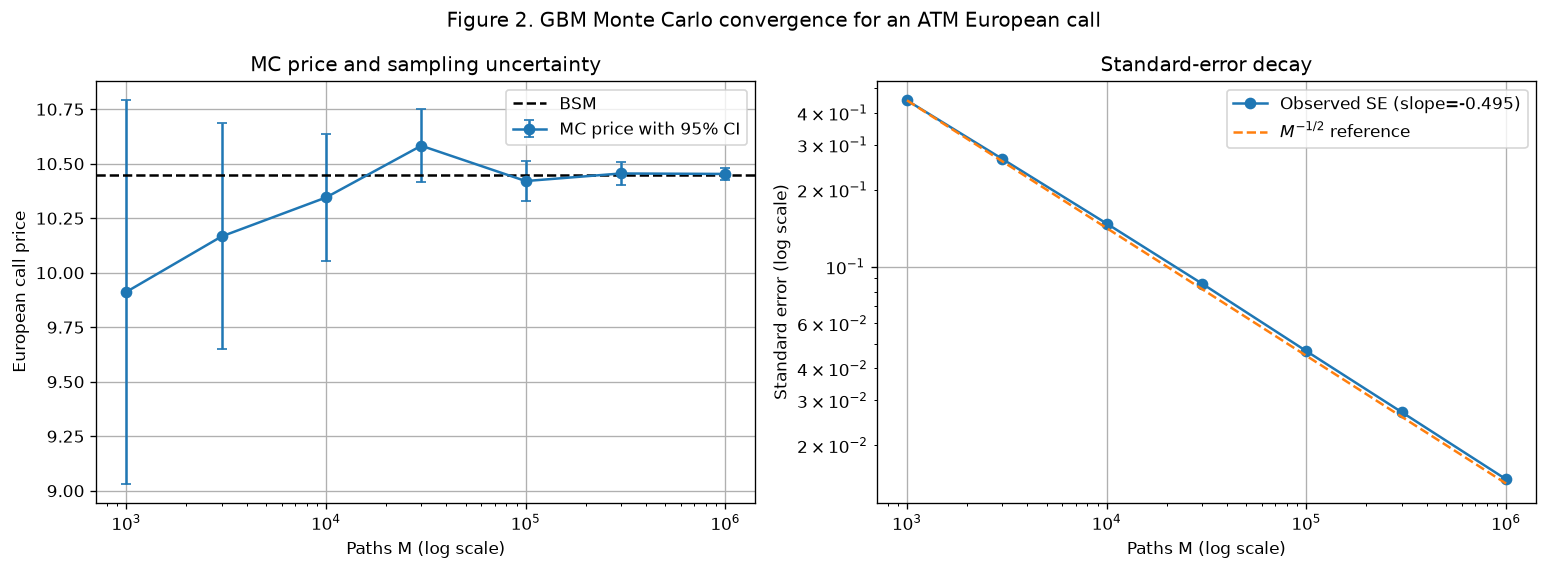

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

"""
신뢰구간에 해당하는 error bar의 길이를 만든다.

mc_price ( 표본 평균 ) ~ ci_high ( 표본 평균 + 1.96SE) 
까지의 길이가 에러바 윗부분의 길이이다.
"""
ci_errors = np.vstack(
    [
        mc_df["mc_price"] - mc_df["ci_low"],
        mc_df["ci_high"] - mc_df["mc_price"],
    ]
)
axes[0].errorbar(
    mc_df["n_paths"],
    mc_df["mc_price"],
    yerr=ci_errors,
    fmt="o-",
    capsize=3,
    color="tab:blue",
    label="MC price with 95% CI",
)
axes[0].axhline(
    bsm_benchmark, color="black", linestyle="--", linewidth=1.5, label="BSM"
)
axes[0].set_xscale("log")
axes[0].set_xlabel("Paths M (log scale)")
axes[0].set_ylabel("European call price")
axes[0].set_title("MC price and sampling uncertainty")
axes[0].legend()

axes[1].plot(
    mc_df["n_paths"],
    mc_df["standard_error"],
    "o-",
    color="tab:blue",
    label=f"Observed SE (slope={se_slope:.3f})",
)
axes[1].plot(
    mc_df["n_paths"],
    mc_df["m_minus_half_reference"],
    linestyle="--",
    color="tab:orange",
    label=r"$M^{-1/2}$ reference",
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Paths M (log scale)")
axes[1].set_ylabel("Standard error (log scale)")
axes[1].set_title("Standard-error decay")
axes[1].legend()

fig.suptitle("Figure 2. GBM Monte Carlo convergence for an ATM European call")
fig.tight_layout()
plt.show()

In [8]:
convergence_checks = pd.Series(
    {
        "bsm_benchmark": bsm_benchmark,
        "crr_4096_price": float(crr_4096["crr_price"]),
        "crr_4096_absolute_error": float(crr_4096["absolute_error"]),
        "crr_4096_error_over_spot": crr_error_over_spot,
        "crr_4096_error_over_spot_lt_1e-4": crr_4096_check,
        "mc_se_log_log_slope": float(se_slope),
        "mc_slope_within_0.05_of_minus_half": abs(se_slope + 0.5) < 0.05,
        "mc_final_price": float(final_mc["mc_price"]),
        "mc_final_standard_error": float(final_mc["standard_error"]),
        "mc_final_absolute_error": float(final_mc["absolute_error"]),
        "mc_final_within_four_standard_errors": final_mc_within_four_se,
    },
    name="value",
)
convergence_checks

bsm_benchmark                          10.4505835722
crr_4096_price                         10.4500953745
crr_4096_absolute_error                 0.0004881976
crr_4096_error_over_spot                0.0000048820
crr_4096_error_over_spot_lt_1e-4                True
mc_se_log_log_slope                    -0.4951487186
mc_slope_within_0.05_of_minus_half              True
mc_final_price                         10.4531952824
mc_final_standard_error                 0.0147314569
mc_final_absolute_error                 0.0026117103
mc_final_within_four_standard_errors            True
Name: value, dtype: object